# Multi-Label Recommendation Evaluation

## 1. Objective

The objective of this experiment is to evaluate whether the new multi-label style model improves outfit recommendations.

The previous experiment showed that the multi-label MobileNetV3 model did not improve top-1 style accuracy compared with the single-label MobileNetV3 model. However, it produced useful combined style outputs, such as:

- sporty + streetwear
- gothic + streetwear
- formal + streetwear

This experiment checks whether those combined style outputs lead to better outfit recommendations.

The main research question is:

**Does using multi-label style predictions improve the quality of outfit recommendations compared with using only one predicted style?**

## 2. Experiment Design

This experiment compares two recommendation modes on the same input images.

| Mode | Style input used for recommendation |
|---|---|
| Old recommendation mode | only the main predicted style |
| New recommendation mode | all predicted styles from the multi-label model |

The same input examples are used for both modes. This keeps the comparison fair.

The recommendation quality will be scored manually using the same criteria as earlier experiments:

| Criterion | Score range | Meaning |
|---|---:|---|
| Style match | 0 to 2 | Does the recommendation match the intended aesthetic? |
| Type match | 0 to 2 | Are the recommended clothing types useful and complete? |
| Visual coherence | 0 to 2 | Do the items look visually compatible together? |
| Overall quality | 0 to 2 | Would this be a usable outfit recommendation? |

To reduce manual work, this experiment starts with 16 examples:

- 4 formal
- 4 gothic
- 4 sporty
- 4 streetwear

## 3. Imports and setup

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

# Reproducibility
random.seed(42)
np.random.seed(42)

print("Setup complete.")

Setup complete.


## 4. Paths

In [2]:
# Input from Experiment 17
multilabel_prediction_path = Path(
    "../results/style_multilabel_training/real_world_multilabel_predictions_threshold_035.csv"
)

# Real-world image folder
real_world_root = Path("../dataset/real_world_test")

# Output folder for this experiment
results_dir = Path("../results/multilabel_recommendation_evaluation")
results_dir.mkdir(parents=True, exist_ok=True)

manual_review_dir = results_dir / "manual_review"
manual_review_dir.mkdir(parents=True, exist_ok=True)

print("Multi-label prediction file exists:", multilabel_prediction_path.exists())
print("Real-world folder exists:", real_world_root.exists())
print("Results folder:", results_dir)

Multi-label prediction file exists: True
Real-world folder exists: True
Results folder: ..\results\multilabel_recommendation_evaluation


## 5. Load Real-World Prediction Table

This table was created in the previous experiment.

It contains the real-world test images, their true style, the main predicted style, and the multi-label style prediction after applying threshold 0.35 with top-1 fallback.

In [3]:
real_world_predictions_df = pd.read_csv(multilabel_prediction_path)

print("Rows:", len(real_world_predictions_df))
print("Columns:", real_world_predictions_df.columns.tolist())

display(real_world_predictions_df.head())

Rows: 80
Columns: ['source', 'split', 'filename', 'image_path', 'true_style', 'type', 'label_formal', 'label_gothic', 'label_sporty', 'label_streetwear', 'predicted_main_style', 'predicted_styles_threshold_fallback', 'predicted_label_count', 'score_formal', 'score_gothic', 'score_sporty', 'score_streetwear', 'top1_correct']


,source,split,filename,image_path,true_style,type,label_formal,label_gothic,label_sporty,label_streetwear,predicted_main_style,predicted_styles_threshold_fallback,predicted_label_count,score_formal,score_gothic,score_sporty,score_streetwear,top1_correct
0,real_world_test,real_world_test,formal_jacket_rw_001.png,..\dataset\real_world_test\formal\jacket\forma...,formal,jacket,1,0,0,0,formal,formal,1,0.571103,0.028740,0.143603,0.214055,True
1,real_world_test,real_world_test,formal_jacket_rw_002.png,..\dataset\real_world_test\formal\jacket\forma...,formal,jacket,1,0,0,0,formal,formal,1,0.906757,0.045820,0.249575,0.192100,True
2,real_world_test,real_world_test,formal_jacket_rw_003.png,..\dataset\real_world_test\formal\jacket\forma...,formal,jacket,1,0,0,0,streetwear,formal + streetwear,2,0.366350,0.212848,0.257413,0.414322,False
3,real_world_test,real_world_test,formal_jacket_rw_004.png,..\dataset\real_world_test\formal\jacket\forma...,formal,jacket,1,0,0,0,formal,formal + streetwear,2,0.772820,0.035382,0.298145,0.464679,True
4,real_world_test,real_world_test,formal_jacket_rw_005.png,..\dataset\real_world_test\formal\jacket\forma...,formal,jacket,1,0,0,0,formal,formal,1,0.527818,0.007305,0.086710,0.079321,True


## 6. Select Balanced Evaluation Examples

To keep the manual work realistic, I select 16 examples from the real-world test set.

The selection is balanced by true style:

- 4 formal examples
- 4 gothic examples
- 4 sporty examples
- 4 streetwear examples

The same 16 examples will be used for both the old and new recommendation modes.

In [4]:
examples_per_style = 4
selected_examples = []

for style in ["formal", "gothic", "sporty", "streetwear"]:
    style_df = real_world_predictions_df[
        real_world_predictions_df["true_style"] == style
    ].copy()

    # Prefer examples where the multi-label model actually predicts multiple styles,
    # because those are the most relevant for this experiment.
    style_df = style_df.sort_values(
        by=["predicted_label_count", "top1_correct"],
        ascending=[False, True]
    )

    selected_style_examples = style_df.head(examples_per_style)

    selected_examples.append(selected_style_examples)

recommendation_eval_examples_df = pd.concat(
    selected_examples,
    ignore_index=True
)

recommendation_eval_examples_df["evaluation_id"] = [
    f"eval_{i + 1:02d}"
    for i in range(len(recommendation_eval_examples_df))
]

selected_examples_path = results_dir / "recommendation_evaluation_examples_16.csv"

recommendation_eval_examples_df.to_csv(selected_examples_path, index=False)

print("Selected examples:", len(recommendation_eval_examples_df))
print("Saved selected examples to:", selected_examples_path)

display(
    recommendation_eval_examples_df[
        [
            "evaluation_id",
            "filename",
            "true_style",
            "predicted_main_style",
            "predicted_styles_threshold_fallback",
            "predicted_label_count",
            "top1_correct",
            "image_path"
        ]
    ]
)

Selected examples: 16
Saved selected examples to: ..\results\multilabel_recommendation_evaluation\recommendation_evaluation_examples_16.csv


,evaluation_id,filename,true_style,predicted_main_style,predicted_styles_threshold_fallback,predicted_label_count,top1_correct,image_path
0,eval_01,formal_jacket_rw_003.png,formal,streetwear,formal + streetwear,2,False,..\dataset\real_world_test\formal\jacket\forma...
1,eval_02,formal_tshirt_rw_002.png,formal,streetwear,formal + streetwear,2,False,..\dataset\real_world_test\formal\tshirt\forma...
2,eval_03,formal_tshirt_rw_003.png,formal,streetwear,sporty + streetwear,2,False,..\dataset\real_world_test\formal\tshirt\forma...
3,eval_04,formal_tshirt_rw_005.png,formal,streetwear,sporty + streetwear,2,False,..\dataset\real_world_test\formal\tshirt\forma...
4,eval_05,gothic_shoes_rw_002.png,gothic,streetwear,gothic + sporty + streetwear,3,False,..\dataset\real_world_test\gothic\shoes\gothic...
5,eval_06,gothic_jacket_rw_005.png,gothic,gothic,formal + gothic,2,True,..\dataset\real_world_test\gothic\jacket\gothi...
6,eval_07,gothic_pants_rw_001.png,gothic,gothic,gothic + streetwear,2,True,..\dataset\real_world_test\gothic\pants\gothic...
7,eval_08,gothic_pants_rw_005.png,gothic,gothic,gothic + streetwear,2,True,..\dataset\real_world_test\gothic\pants\gothic...
8,eval_09,sporty_tshirt_rw_003.png,sporty,streetwear,formal + sporty + streetwear,3,False,..\dataset\real_world_test\sporty\tshirt\sport...
9,eval_10,sporty_jacket_rw_004.png,sporty,formal,formal + sporty,2,False,..\dataset\real_world_test\sporty\jacket\sport...


## 7. Load Catalogue Items

The recommendation system needs catalogue items to recommend from.

The catalogue comes from the cleaned dataset. Each image is stored by style and clothing type, for example:

```text
dataset/cleaned/streetwear/shoes/image.png
```

For each catalogue item, I store:

  * image path
  * style
  * clothing type
  * filename

In [5]:
catalogue_root = Path("../dataset/cleaned")

valid_extensions = (".jpg", ".jpeg", ".png", ".webp")

catalogue_rows = []

for style in sorted(os.listdir(catalogue_root)):
    style_path = catalogue_root / style

    if not style_path.is_dir():
        continue

    for item_type in sorted(os.listdir(style_path)):
        type_path = style_path / item_type

        if not type_path.is_dir():
            continue

        for filename in sorted(os.listdir(type_path)):
            image_path = type_path / filename

            if image_path.is_file() and filename.lower().endswith(valid_extensions):
                catalogue_rows.append({
                    "catalogue_filename": filename,
                    "catalogue_image_path": str(image_path),
                    "catalogue_style": style,
                    "catalogue_type": item_type
                })

catalogue_df = pd.DataFrame(catalogue_rows)

print("Catalogue items:", len(catalogue_df))
display(catalogue_df.head())
display(catalogue_df.groupby(["catalogue_style", "catalogue_type"]).size().reset_index(name="count"))

Catalogue items: 800


,catalogue_filename,catalogue_image_path,catalogue_style,catalogue_type
0,formal_jacket_001.png,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket
1,formal_jacket_002.png,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket
2,formal_jacket_003.png,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket
3,formal_jacket_004.png,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket
4,formal_jacket_005.png,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket


,catalogue_style,catalogue_type,count
0,formal,jacket,50
1,formal,pants,50
2,formal,shoes,50
3,formal,tshirt,50
4,gothic,jacket,50
5,gothic,pants,50
6,gothic,shoes,50
7,gothic,tshirt,50
8,sporty,jacket,50
9,sporty,pants,50


## 8. Helper Functions

This section prepares helper functions for the recommendation comparison.

The old mode uses only the main predicted style.

The new mode uses all predicted styles from the multi-label model.

For each input image, the system recommends one item from each missing clothing type. For example, if the uploaded item is a `t-shirt`, the system recommends:

- jacket
- pants
- shoes

In [6]:
target_types = ["jacket", "pants", "shoes", "tshirt"]


def parse_style_list(style_text):
    return [
        style.strip()
        for style in str(style_text).split("+")
        if style.strip()
    ]


def infer_input_type_from_path(image_path):
    path_parts = Path(str(image_path).replace("\\", "/")).parts

    for item_type in target_types:
        if item_type in path_parts:
            return item_type

    return "unknown"


def get_missing_types(input_type):
    return [
        item_type
        for item_type in target_types
        if item_type != input_type
    ]


recommendation_eval_examples_df["input_type"] = recommendation_eval_examples_df["image_path"].apply(
    infer_input_type_from_path
)

display(
    recommendation_eval_examples_df[
        [
            "evaluation_id",
            "filename",
            "true_style",
            "input_type",
            "predicted_main_style",
            "predicted_styles_threshold_fallback"
        ]
    ]
)

,evaluation_id,filename,true_style,input_type,predicted_main_style,predicted_styles_threshold_fallback
0,eval_01,formal_jacket_rw_003.png,formal,jacket,streetwear,formal + streetwear
1,eval_02,formal_tshirt_rw_002.png,formal,tshirt,streetwear,formal + streetwear
2,eval_03,formal_tshirt_rw_003.png,formal,tshirt,streetwear,sporty + streetwear
3,eval_04,formal_tshirt_rw_005.png,formal,tshirt,streetwear,sporty + streetwear
4,eval_05,gothic_shoes_rw_002.png,gothic,shoes,streetwear,gothic + sporty + streetwear
5,eval_06,gothic_jacket_rw_005.png,gothic,jacket,gothic,formal + gothic
6,eval_07,gothic_pants_rw_001.png,gothic,pants,gothic,gothic + streetwear
7,eval_08,gothic_pants_rw_005.png,gothic,pants,gothic,gothic + streetwear
8,eval_09,sporty_tshirt_rw_003.png,sporty,tshirt,streetwear,formal + sporty + streetwear
9,eval_10,sporty_jacket_rw_004.png,sporty,jacket,formal,formal + sporty


## 9. Generate Old and New Recommendation Sets

This section creates recommendation sets for each selected input image.

The old recommendation mode filters catalogue items using only the main predicted style.

The new recommendation mode filters catalogue items using all predicted styles from the multi-label output.

To keep the comparison simple and fair, the same rule is used in both modes:

- recommend one item for each missing clothing type
- choose from the matching style pool
- use a fixed random seed for reproducibility

This creates a manual review table where each input image has two recommendation outputs to compare.

In [7]:
def choose_recommendation_items(catalogue_df, allowed_styles, input_type, random_state=42):
    recommended_items = []

    missing_types = get_missing_types(input_type)

    for missing_type in missing_types:
        candidates = catalogue_df[
            (catalogue_df["catalogue_style"].isin(allowed_styles)) &
            (catalogue_df["catalogue_type"] == missing_type)
        ].copy()

        if len(candidates) == 0:
            recommended_items.append({
                "recommended_type": missing_type,
                "recommended_style": "none",
                "recommended_filename": "no_candidate_found",
                "recommended_image_path": ""
            })
            continue

        selected_candidate = candidates.sample(
            n=1,
            random_state=random_state
        ).iloc[0]

        recommended_items.append({
            "recommended_type": missing_type,
            "recommended_style": selected_candidate["catalogue_style"],
            "recommended_filename": selected_candidate["catalogue_filename"],
            "recommended_image_path": selected_candidate["catalogue_image_path"]
        })

    return recommended_items


recommendation_rows = []

for _, row in recommendation_eval_examples_df.iterrows():
    old_styles = [row["predicted_main_style"]]
    new_styles = parse_style_list(row["predicted_styles_threshold_fallback"])

    modes = [
        {
            "recommendation_mode": "old_single_style",
            "allowed_styles": old_styles
        },
        {
            "recommendation_mode": "new_multi_style",
            "allowed_styles": new_styles
        }
    ]

    for mode in modes:
        recommended_items = choose_recommendation_items(
            catalogue_df=catalogue_df,
            allowed_styles=mode["allowed_styles"],
            input_type=row["input_type"],
            random_state=42
        )

        recommendation_entry = {
            "evaluation_id": row["evaluation_id"],
            "filename": row["filename"],
            "input_image_path": row["image_path"],
            "true_style": row["true_style"],
            "input_type": row["input_type"],
            "predicted_main_style": row["predicted_main_style"],
            "predicted_styles_threshold_fallback": row["predicted_styles_threshold_fallback"],
            "recommendation_mode": mode["recommendation_mode"],
            "allowed_styles": " + ".join(mode["allowed_styles"])
        }

        for item in recommended_items:
            item_type = item["recommended_type"]

            recommendation_entry[f"{item_type}_style"] = item["recommended_style"]
            recommendation_entry[f"{item_type}_filename"] = item["recommended_filename"]
            recommendation_entry[f"{item_type}_image_path"] = item["recommended_image_path"]

        recommendation_rows.append(recommendation_entry)

recommendation_comparison_df = pd.DataFrame(recommendation_rows)

recommendation_comparison_path = results_dir / "recommendation_comparison_old_vs_new.csv"

recommendation_comparison_df.to_csv(recommendation_comparison_path, index=False)

print("Recommendation rows:", len(recommendation_comparison_df))
print("Saved comparison table to:", recommendation_comparison_path)

display(recommendation_comparison_df.head(10))

Recommendation rows: 32
Saved comparison table to: ..\results\multilabel_recommendation_evaluation\recommendation_comparison_old_vs_new.csv


,evaluation_id,filename,input_image_path,true_style,input_type,predicted_main_style,predicted_styles_threshold_fallback,recommendation_mode,allowed_styles,pants_style,...,pants_image_path,shoes_style,shoes_filename,shoes_image_path,tshirt_style,tshirt_filename,tshirt_image_path,jacket_style,jacket_filename,jacket_image_path
0,eval_01,formal_jacket_rw_003.png,..\dataset\real_world_test\formal\jacket\forma...,formal,jacket,streetwear,formal + streetwear,old_single_style,streetwear,streetwear,...,..\dataset\cleaned\streetwear\pants\streetwear...,streetwear,streetwear_shoes_014.png,..\dataset\cleaned\streetwear\shoes\streetwear...,streetwear,streetwear_tshirt_014.png,..\dataset\cleaned\streetwear\tshirt\streetwea...,NaN,NaN,NaN
1,eval_01,formal_jacket_rw_003.png,..\dataset\real_world_test\formal\jacket\forma...,formal,jacket,streetwear,formal + streetwear,new_multi_style,formal + streetwear,streetwear,...,..\dataset\cleaned\streetwear\pants\streetwear...,streetwear,streetwear_shoes_034.png,..\dataset\cleaned\streetwear\shoes\streetwear...,streetwear,streetwear_tshirt_034.png,..\dataset\cleaned\streetwear\tshirt\streetwea...,NaN,NaN,NaN
2,eval_02,formal_tshirt_rw_002.png,..\dataset\real_world_test\formal\tshirt\forma...,formal,tshirt,streetwear,formal + streetwear,old_single_style,streetwear,streetwear,...,..\dataset\cleaned\streetwear\pants\streetwear...,streetwear,streetwear_shoes_014.png,..\dataset\cleaned\streetwear\shoes\streetwear...,NaN,NaN,NaN,streetwear,streetwear_jacket_014.png,..\dataset\cleaned\streetwear\jacket\streetwea...
3,eval_02,formal_tshirt_rw_002.png,..\dataset\real_world_test\formal\tshirt\forma...,formal,tshirt,streetwear,formal + streetwear,new_multi_style,formal + streetwear,streetwear,...,..\dataset\cleaned\streetwear\pants\streetwear...,streetwear,streetwear_shoes_034.png,..\dataset\cleaned\streetwear\shoes\streetwear...,NaN,NaN,NaN,streetwear,streetwear_jacket_034.png,..\dataset\cleaned\streetwear\jacket\streetwea...
4,eval_03,formal_tshirt_rw_003.png,..\dataset\real_world_test\formal\tshirt\forma...,formal,tshirt,streetwear,sporty + streetwear,old_single_style,streetwear,streetwear,...,..\dataset\cleaned\streetwear\pants\streetwear...,streetwear,streetwear_shoes_014.png,..\dataset\cleaned\streetwear\shoes\streetwear...,NaN,NaN,NaN,streetwear,streetwear_jacket_014.png,..\dataset\cleaned\streetwear\jacket\streetwea...
5,eval_03,formal_tshirt_rw_003.png,..\dataset\real_world_test\formal\tshirt\forma...,formal,tshirt,streetwear,sporty + streetwear,new_multi_style,sporty + streetwear,streetwear,...,..\dataset\cleaned\streetwear\pants\streetwear...,streetwear,streetwear_shoes_034.png,..\dataset\cleaned\streetwear\shoes\streetwear...,NaN,NaN,NaN,streetwear,streetwear_jacket_034.png,..\dataset\cleaned\streetwear\jacket\streetwea...
6,eval_04,formal_tshirt_rw_005.png,..\dataset\real_world_test\formal\tshirt\forma...,formal,tshirt,streetwear,sporty + streetwear,old_single_style,streetwear,streetwear,...,..\dataset\cleaned\streetwear\pants\streetwear...,streetwear,streetwear_shoes_014.png,..\dataset\cleaned\streetwear\shoes\streetwear...,NaN,NaN,NaN,streetwear,streetwear_jacket_014.png,..\dataset\cleaned\streetwear\jacket\streetwea...
7,eval_04,formal_tshirt_rw_005.png,..\dataset\real_world_test\formal\tshirt\forma...,formal,tshirt,streetwear,sporty + streetwear,new_multi_style,sporty + streetwear,streetwear,...,..\dataset\cleaned\streetwear\pants\streetwear...,streetwear,streetwear_shoes_034.png,..\dataset\cleaned\streetwear\shoes\streetwear...,NaN,NaN,NaN,streetwear,streetwear_jacket_034.png,..\dataset\cleaned\streetwear\jacket\streetwea...
8,eval_05,gothic_shoes_rw_002.png,..\dataset\real_world_test\gothic\shoes\gothic...,gothic,shoes,streetwear,gothic + sporty + streetwear,old_single_style,streetwear,streetwear,...,..\dataset\cleaned\streetwear\pants\streetwear...,NaN,NaN,NaN,streetwear,streetwear_tshirt_014.png,..\dataset\cleaned\streetwear\tshirt\streetwea...,streetwear,streetwear_jacket_014.png,..\dataset\c

## 10. Create Manual Scoring Sheet

The generated recommendation sets now need to be scored manually.

Each selected input image has two recommendation modes:

- old_single_style
- new_multi_style

The manual score columns are left empty and will be filled after visually inspecting the recommendations.

In [8]:
manual_scoring_df = recommendation_comparison_df.copy()

manual_scoring_df["style_match_score"] = ""
manual_scoring_df["type_match_score"] = ""
manual_scoring_df["visual_coherence_score"] = ""
manual_scoring_df["overall_quality_score"] = ""
manual_scoring_df["manual_notes"] = ""

manual_scoring_path = manual_review_dir / "recommendation_manual_scoring_template.xlsx"
manual_scoring_csv_path = manual_review_dir / "recommendation_manual_scoring_template.csv"

manual_scoring_df.to_excel(manual_scoring_path, index=False)
manual_scoring_df.to_csv(manual_scoring_csv_path, index=False)

print("Saved manual scoring Excel to:", manual_scoring_path)
print("Saved manual scoring CSV to:", manual_scoring_csv_path)
print("Rows to score:", len(manual_scoring_df))

display(
    manual_scoring_df[
        [
            "evaluation_id",
            "filename",
            "true_style",
            "input_type",
            "recommendation_mode",
            "allowed_styles",
            "style_match_score",
            "type_match_score",
            "visual_coherence_score",
            "overall_quality_score",
            "manual_notes"
        ]
    ].head(10)
)

Saved manual scoring Excel to: ..\results\multilabel_recommendation_evaluation\manual_review\recommendation_manual_scoring_template.xlsx
Saved manual scoring CSV to: ..\results\multilabel_recommendation_evaluation\manual_review\recommendation_manual_scoring_template.csv
Rows to score: 32


,evaluation_id,filename,true_style,input_type,recommendation_mode,allowed_styles,style_match_score,type_match_score,visual_coherence_score,overall_quality_score,manual_notes
0,eval_01,formal_jacket_rw_003.png,formal,jacket,old_single_style,streetwear,,,,,
1,eval_01,formal_jacket_rw_003.png,formal,jacket,new_multi_style,formal + streetwear,,,,,
2,eval_02,formal_tshirt_rw_002.png,formal,tshirt,old_single_style,streetwear,,,,,
3,eval_02,formal_tshirt_rw_002.png,formal,tshirt,new_multi_style,formal + streetwear,,,,,
4,eval_03,formal_tshirt_rw_003.png,formal,tshirt,old_single_style,streetwear,,,,,
5,eval_03,formal_tshirt_rw_003.png,formal,tshirt,new_multi_style,sporty + streetwear,,,,,
6,eval_04,formal_tshirt_rw_005.png,formal,tshirt,old_single_style,streetwear,,,,,
7,eval_04,formal_tshirt_rw_005.png,formal,tshirt,new_multi_style,sporty + streetwear,,,,,
8,eval_05,gothic_shoes_rw_002.png,gothic,shoes,old_single_style,streetwear,,,,,
9,eval_05,gothic_shoes_rw_002.png,gothic,shoes,new_multi_style,gothic + sporty + streetwear,,,,,


## 11. Create Visual Recommendation Comparison Sheets

To make manual scoring easier, I create visual comparison sheets.

Each sheet shows one input image and the two recommendation modes:

- old_single_style
- new_multi_style

This allows the recommendation quality to be scored visually instead of opening each image path manually.

In [9]:
visual_sheet_dir = manual_review_dir / "visual_comparison_sheets"
visual_sheet_dir.mkdir(parents=True, exist_ok=True)


def show_image_on_axis(ax, image_path, title):
    try:
        image = Image.open(image_path).convert("RGB")
        ax.imshow(image)
        ax.set_title(title, fontsize=9)
    except Exception:
        ax.text(
            0.5,
            0.5,
            f"Image not found:\n{image_path}",
            ha="center",
            va="center",
            wrap=True
        )
        ax.set_title(title, fontsize=9)

    ax.axis("off")


def get_recommended_image_paths(row):
    recommended_paths = []

    for item_type in target_types:
        path_col = f"{item_type}_image_path"
        style_col = f"{item_type}_style"

        if path_col in row.index and pd.notna(row[path_col]) and str(row[path_col]).strip() != "":
            recommended_paths.append({
                "type": item_type,
                "style": row[style_col],
                "path": row[path_col]
            })

    return recommended_paths


saved_visual_sheets = []

for evaluation_id in recommendation_eval_examples_df["evaluation_id"]:
    example_rows = recommendation_comparison_df[
        recommendation_comparison_df["evaluation_id"] == evaluation_id
    ].copy()

    input_row = example_rows.iloc[0]

    old_row = example_rows[
        example_rows["recommendation_mode"] == "old_single_style"
    ].iloc[0]

    new_row = example_rows[
        example_rows["recommendation_mode"] == "new_multi_style"
    ].iloc[0]

    old_items = get_recommended_image_paths(old_row)
    new_items = get_recommended_image_paths(new_row)

    fig, axes = plt.subplots(
        3,
        4,
        figsize=(14, 10)
    )

    # Row 1: input image
    show_image_on_axis(
        axes[0, 0],
        input_row["input_image_path"],
        (
            f"Input: {evaluation_id}\n"
            f"True: {input_row['true_style']} | Type: {input_row['input_type']}\n"
            f"Main pred: {input_row['predicted_main_style']}\n"
            f"Multi pred: {input_row['predicted_styles_threshold_fallback']}"
        )
    )

    for col in range(1, 4):
        axes[0, col].axis("off")

    # Row 2: old recommendation mode
    axes[1, 0].text(
        0.5,
        0.5,
        f"OLD MODE\nAllowed style:\n{old_row['allowed_styles']}",
        ha="center",
        va="center",
        fontsize=11
    )
    axes[1, 0].axis("off")

    for col, item in enumerate(old_items, start=1):
        show_image_on_axis(
            axes[1, col],
            item["path"],
            f"{item['type']}\n{item['style']}"
        )

    # Row 3: new recommendation mode
    axes[2, 0].text(
        0.5,
        0.5,
        f"NEW MODE\nAllowed styles:\n{new_row['allowed_styles']}",
        ha="center",
        va="center",
        fontsize=11
    )
    axes[2, 0].axis("off")

    for col, item in enumerate(new_items, start=1):
        show_image_on_axis(
            axes[2, col],
            item["path"],
            f"{item['type']}\n{item['style']}"
        )

    plt.tight_layout()

    save_path = visual_sheet_dir / f"{evaluation_id}_old_vs_new_recommendation.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    saved_visual_sheets.append(save_path)

print("Saved visual comparison sheets:", len(saved_visual_sheets))

for path in saved_visual_sheets[:5]:
    print(path)

Saved visual comparison sheets: 16
..\results\multilabel_recommendation_evaluation\manual_review\visual_comparison_sheets\eval_01_old_vs_new_recommendation.png
..\results\multilabel_recommendation_evaluation\manual_review\visual_comparison_sheets\eval_02_old_vs_new_recommendation.png
..\results\multilabel_recommendation_evaluation\manual_review\visual_comparison_sheets\eval_03_old_vs_new_recommendation.png
..\results\multilabel_recommendation_evaluation\manual_review\visual_comparison_sheets\eval_04_old_vs_new_recommendation.png
..\results\multilabel_recommendation_evaluation\manual_review\visual_comparison_sheets\eval_05_old_vs_new_recommendation.png


## 12. First Visual Sheet

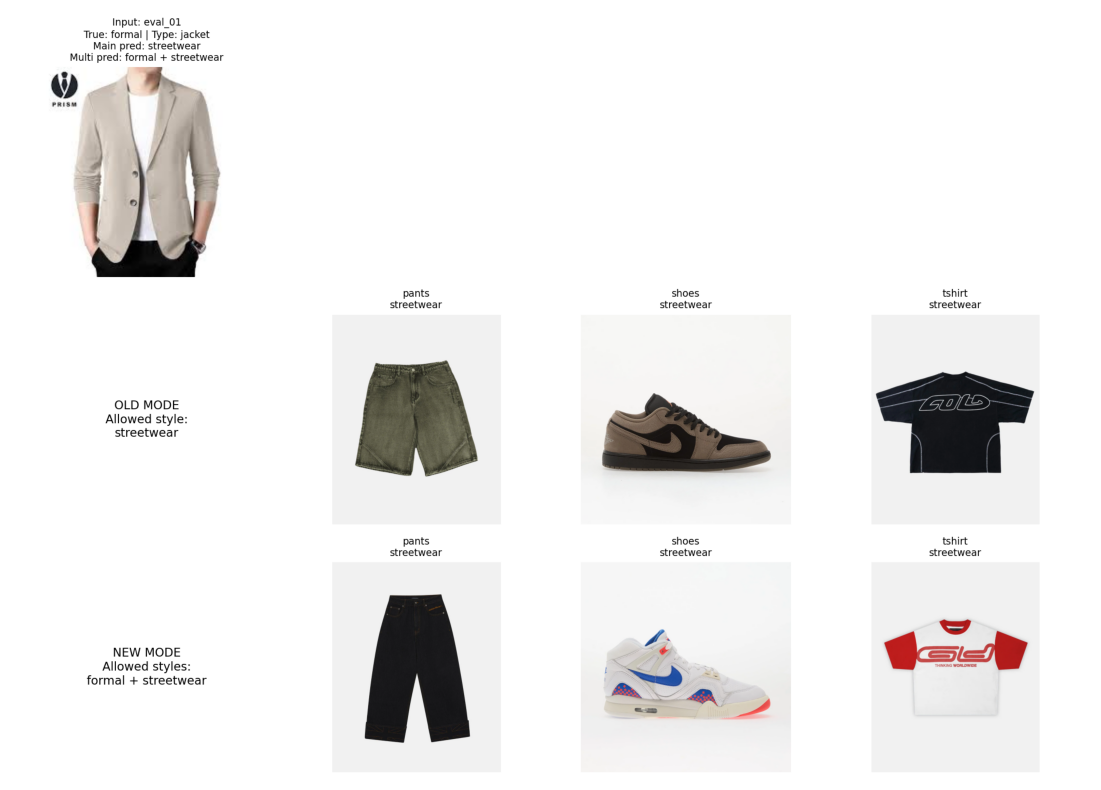

In [10]:
first_visual_sheet = saved_visual_sheets[0]

img = Image.open(first_visual_sheet)

plt.figure(figsize=(14, 10))
plt.imshow(img)
plt.axis("off")
plt.show()

## 13. Manual Scoring Instructions

Each recommendation mode is scored from 0 to 2 on four criteria:

| Criterion | 0 | 1 | 2 |
|---|---|---|---|
| Style match | wrong style | partially fits | clearly fits |
| Type match | missing/wrong types | partly useful | useful complete outfit |
| Visual coherence | items clash | acceptable | visually coherent |
| Overall quality | bad recommendation | usable but weak | good recommendation |

The goal is not to score whether the classifier was correct. The goal is to score whether the recommended outfit is useful for the input image.

## 14. Load Completed Manual Scoring Sheet

The manual recommendation scoring has now been completed.

This section loads the completed Excel file back into the notebook so the old single-style recommendation mode and the new multi-style recommendation mode can be compared.

In [11]:
completed_scoring_path = manual_review_dir / "recommendation_manual_scoring_completed.xlsx"

manual_scoring_completed_df = pd.read_excel(completed_scoring_path)

print("Completed scoring file:", completed_scoring_path)
print("Rows loaded:", len(manual_scoring_completed_df))
print("Columns:", manual_scoring_completed_df.columns.tolist())

display(manual_scoring_completed_df.head())

Completed scoring file: ..\results\multilabel_recommendation_evaluation\manual_review\recommendation_manual_scoring_completed.xlsx
Rows loaded: 32
Columns: ['evaluation_id', 'filename', 'input_image_path', 'true_style', 'input_type', 'predicted_main_style', 'predicted_styles_threshold_fallback', 'recommendation_mode', 'allowed_styles', 'pants_style', 'pants_filename', 'pants_image_path', 'shoes_style', 'shoes_filename', 'shoes_image_path', 'tshirt_style', 'tshirt_filename', 'tshirt_image_path', 'jacket_style', 'jacket_filename', 'jacket_image_path', 'style_match_score', 'type_match_score', 'visual_coherence_score', 'overall_quality_score', 'manual_notes']


,evaluation_id,filename,input_image_path,true_style,input_type,predicted_main_style,predicted_styles_threshold_fallback,recommendation_mode,allowed_styles,pants_style,...,tshirt_filename,tshirt_image_path,jacket_style,jacket_filename,jacket_image_path,style_match_score,type_match_score,visual_coherence_score,overall_quality_score,manual_notes
0,eval_01,formal_jacket_rw_003.png,..\dataset\real_world_test\formal\jacket\forma...,formal,jacket,streetwear,formal + streetwear,old_single_style,streetwear,streetwear,...,streetwear_tshirt_014.png,..\dataset\cleaned\streetwear\tshirt\streetwea...,NaN,NaN,NaN,1,2,1,1,"Complete outfit, but too streetwear for a form..."
1,eval_01,formal_jacket_rw_003.png,..\dataset\real_world_test\formal\jacket\forma...,formal,jacket,streetwear,formal + streetwear,new_multi_style,formal + streetwear,streetwear,...,streetwear_tshirt_034.png,..\dataset\cleaned\streetwear\tshirt\streetwea...,NaN,NaN,NaN,1,2,1,1,"Black pants help, but the colorful shoes and t..."
2,eval_02,formal_tshirt_rw_002.png,..\dataset\real_world_test\formal\tshirt\forma...,formal,tshirt,streetwear,formal + streetwear,old_single_style,streetwear,streetwear,...,NaN,NaN,streetwear,streetwear_jacket_014.png,..\dataset\cleaned\streetwear\jacket\streetwea...,0,2,1,1,"The recommendation is complete, but the street..."
3,eval_02,formal_tshirt_rw_002.png,..\dataset\real_world_test\formal\tshirt\forma...,formal,tshirt,streetwear,formal + streetwear,new_multi_style,formal + streetwear,streetwear,...,NaN,NaN,streetwear,streetwear_jacket_034.png,..\dataset\cleaned\streetwear\jacket\streetwea...,0,2,0,0,The sporty purple jacket and bright shoes clas...
4,eval_03,formal_tshirt_rw_003.png,..\dataset\real_world_test\formal\tshirt\forma...,formal,tshirt,streetwear,sporty + streetwear,old_single_style,streetwear,streetwear,...,NaN,NaN,streetwear,streetwear_jacket_014.png,..\dataset\cleaned\streetwear\jacket\streetwea...,0,2,1,1,"The outfit is complete, but the streetwear ite..."


## 15. Validate Manual Scores

Before calculating the final results, the manual scores are validated.

Each score should be between 0 and 2.

In [12]:
score_columns = [
    "style_match_score",
    "type_match_score",
    "visual_coherence_score",
    "overall_quality_score"
]

required_columns = [
    "evaluation_id",
    "recommendation_mode"
] + score_columns

missing_columns = [
    col for col in required_columns
    if col not in manual_scoring_completed_df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

for col in score_columns:
    manual_scoring_completed_df[col] = pd.to_numeric(
        manual_scoring_completed_df[col],
        errors="coerce"
    )

missing_score_rows = manual_scoring_completed_df[
    manual_scoring_completed_df[score_columns].isna().any(axis=1)
]

invalid_score_rows = manual_scoring_completed_df[
    ~manual_scoring_completed_df[score_columns].apply(
        lambda col: col.between(0, 2)
    ).all(axis=1)
]

print("Rows with missing scores:", len(missing_score_rows))
print("Rows with invalid scores:", len(invalid_score_rows))

if len(missing_score_rows) > 0:
    display(missing_score_rows[["evaluation_id", "recommendation_mode"] + score_columns])

if len(invalid_score_rows) > 0:
    display(invalid_score_rows[["evaluation_id", "recommendation_mode"] + score_columns])

manual_scoring_completed_df["total_score"] = manual_scoring_completed_df[score_columns].sum(axis=1)

print("Score validation complete.")
display(manual_scoring_completed_df[
    ["evaluation_id", "recommendation_mode"] + score_columns + ["total_score"]
].head())

Rows with missing scores: 0
Rows with invalid scores: 0
Score validation complete.


,evaluation_id,recommendation_mode,style_match_score,type_match_score,visual_coherence_score,overall_quality_score,total_score
0,eval_01,old_single_style,1,2,1,1,5
1,eval_01,new_multi_style,1,2,1,1,5
2,eval_02,old_single_style,0,2,1,1,4
3,eval_02,new_multi_style,0,2,0,0,2
4,eval_03,old_single_style,0,2,1,1,4


## 16. Compare Old and New Recommendation Modes

This section calculates the average score for each recommendation mode.

The old mode uses only the main predicted style.  
The new mode uses the multi-label style prediction.

In [13]:
mode_summary = manual_scoring_completed_df.groupby("recommendation_mode").agg(
    examples=("evaluation_id", "count"),
    avg_style_match=("style_match_score", "mean"),
    avg_type_match=("type_match_score", "mean"),
    avg_visual_coherence=("visual_coherence_score", "mean"),
    avg_overall_quality=("overall_quality_score", "mean"),
    avg_total_score=("total_score", "mean")
).reset_index()

display(mode_summary)

mode_summary_path = results_dir / "recommendation_mode_score_summary.csv"
mode_summary.to_csv(mode_summary_path, index=False)

print("Saved mode summary to:", mode_summary_path)

,recommendation_mode,examples,avg_style_match,avg_type_match,avg_visual_coherence,avg_overall_quality,avg_total_score
0,new_multi_style,16,1.0625,2.0,0.875,1.0000,4.9375
1,old_single_style,16,1.0625,2.0,1.125,1.3125,5.5000


Saved mode summary to: ..\results\multilabel_recommendation_evaluation\recommendation_mode_score_summary.csv


## 17. Paired Comparison Per Input Image

Because both recommendation modes were tested on the same input images, this section compares old and new mode per evaluation example.

This shows whether the new multi-label recommendation improved, worsened, or stayed equal for each input.

In [14]:
paired_scores = manual_scoring_completed_df.pivot(
    index="evaluation_id",
    columns="recommendation_mode",
    values="total_score"
).reset_index()

paired_scores["score_difference_new_minus_old"] = (
    paired_scores["new_multi_style"] - paired_scores["old_single_style"]
)

paired_scores["comparison_result"] = paired_scores["score_difference_new_minus_old"].apply(
    lambda diff: "new_better" if diff > 0 else ("old_better" if diff < 0 else "equal")
)

display(paired_scores)

comparison_counts = paired_scores["comparison_result"].value_counts().reset_index()
comparison_counts.columns = ["comparison_result", "count"]

display(comparison_counts)

paired_scores_path = results_dir / "paired_recommendation_score_comparison.csv"
paired_scores.to_csv(paired_scores_path, index=False)

print("Saved paired comparison to:", paired_scores_path)

recommendation_mode,evaluation_id,new_multi_style,old_single_style,score_difference_new_minus_old,comparison_result
0,eval_01,5,5,0,equal
1,eval_02,2,4,-2,old_better
2,eval_03,2,4,-2,old_better
3,eval_04,2,5,-3,old_better
4,eval_05,2,5,-3,old_better
5,eval_06,8,7,1,new_better
6,eval_07,2,7,-5,old_better
7,eval_08,2,7,-5,old_better
8,eval_09,6,5,1,new_better
9,eval_10,8,5,3,new_better


,comparison_result,count
0,old_better,7
1,new_better,6
2,equal,3


Saved paired comparison to: ..\results\multilabel_recommendation_evaluation\paired_recommendation_score_comparison.csv


## 18. Final Recommendation Evaluation Summary

This section saves the final result of the recommendation evaluation.

The result shows whether using multi-label style predictions improved the recommendation quality compared with using only one predicted style.

In [15]:
old_summary = mode_summary[
    mode_summary["recommendation_mode"] == "old_single_style"
].iloc[0]

new_summary = mode_summary[
    mode_summary["recommendation_mode"] == "new_multi_style"
].iloc[0]

final_recommendation_summary = {
    "experiment": "18_fashion_multilabel_recommendation_evaluation",
    "evaluated_examples": int(len(paired_scores)),
    "total_scored_rows": int(len(manual_scoring_completed_df)),
    "old_avg_style_match": old_summary["avg_style_match"],
    "new_avg_style_match": new_summary["avg_style_match"],
    "old_avg_type_match": old_summary["avg_type_match"],
    "new_avg_type_match": new_summary["avg_type_match"],
    "old_avg_visual_coherence": old_summary["avg_visual_coherence"],
    "new_avg_visual_coherence": new_summary["avg_visual_coherence"],
    "old_avg_overall_quality": old_summary["avg_overall_quality"],
    "new_avg_overall_quality": new_summary["avg_overall_quality"],
    "old_avg_total_score": old_summary["avg_total_score"],
    "new_avg_total_score": new_summary["avg_total_score"],
    "avg_total_score_difference_new_minus_old": (
        new_summary["avg_total_score"] - old_summary["avg_total_score"]
    ),
    "new_better_count": int((paired_scores["comparison_result"] == "new_better").sum()),
    "old_better_count": int((paired_scores["comparison_result"] == "old_better").sum()),
    "equal_count": int((paired_scores["comparison_result"] == "equal").sum())
}

final_recommendation_summary_df = pd.DataFrame([final_recommendation_summary])

final_summary_path = results_dir / "final_recommendation_evaluation_summary.csv"

final_recommendation_summary_df.to_csv(final_summary_path, index=False)

print("Saved final recommendation summary to:", final_summary_path)

display(final_recommendation_summary_df)

Saved final recommendation summary to: ..\results\multilabel_recommendation_evaluation\final_recommendation_evaluation_summary.csv


,experiment,evaluated_examples,total_scored_rows,old_avg_style_match,new_avg_style_match,old_avg_type_match,new_avg_type_match,old_avg_visual_coherence,new_avg_visual_coherence,old_avg_overall_quality,new_avg_overall_quality,old_avg_total_score,new_avg_total_score,avg_total_score_difference_new_minus_old,new_better_count,old_better_count,equal_count
0,18_fashion_multilabel_recommendation_evaluation,16,32,1.0625,1.0625,2.0,2.0,1.125,0.875,1.3125,1.0,5.5,4.9375,-0.5625,6,7,3


## 19. Result Interpretation

The manual scoring shows that the new multi-label recommendation mode did not improve the recommendation quality overall.

The old single-style recommendation mode achieved an average total score of 5.50, while the new multi-style recommendation mode achieved an average total score of 4.94.

The style match score was equal for both modes, and the type match score was also equal. This means both systems selected complete outfits with the correct missing clothing types. However, the old mode performed better in visual coherence and overall quality.

The paired comparison also shows a mixed result:

- old mode was better for 7 examples
- new mode was better for 6 examples
- both modes were equal for 3 examples

This suggests that multi-label predictions can help in some cases, especially for sporty and streetwear overlap. However, simply allowing more styles into the recommendation pool does not automatically improve the final outfit. In some cases, it makes the recommendation less coherent because the selected items come from different style directions.

## 20. Final Conclusion

This experiment tested whether using multi-label style predictions improves outfit recommendation quality compared with using only one predicted style.

The result shows that the new multi-label recommendation mode did not outperform the old single-style mode in this setup. The old mode achieved a higher average total score, mainly because it produced more visually coherent recommendations.

However, this does not mean the multi-label model is useless. The experiment shows that multi-label style prediction is useful information, but it should not be used as a simple style filter. When multiple styles are allowed without ranking, the recommendation system can pick items that match different aesthetics but do not work well together as one outfit.

The main conclusion is that the recommendation system needs a better ranking step. The most logical next improvement is to combine multi-label style predictions with CLIP visual similarity ranking. This would allow the system to use multiple possible aesthetics while still selecting items that visually match the uploaded clothing item.

Therefore, the multi-label model should not replace the old recommendation logic by itself. It should be used as an additional input for a stronger recommendation ranking system.